# Simulations and testing

These simulations are based on the `simulation_master.py` module. All simulations are versions of AR(1) models.

First we import relevant libraries and the module file.

In [37]:
# to run R code
%load_ext rpy2.ipython

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib

# add path to the module
sys.path.append(os.path.abspath(".."))

# import functions
from simulation import simulation_master

# reload functions
importlib.reload(simulation_master)

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


<module 'simulation.simulation_master' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/simulation/simulation_master.py'>

### Random walk with drift - no bubble

First we simulate, plot and save $P_t$ as .csv file.

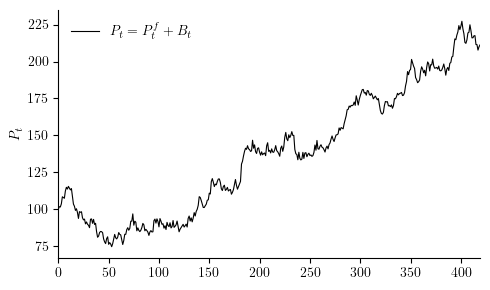

In [34]:
# simulate random walk with drift - no bubble

Pf_nobubble, B_nobubble, P_nobubble = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 420,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.2,
    sigma_f = 3,
    Pf0 = 100.0,

    # Random seed
    seed = 42,
    
)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_nobubble.index, P_nobubble.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P.index.min(), P.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_nobubble.pdf')
P_nobubble = P_nobubble.rename('P_nobubble')
P_nobubble.to_csv('data/P_nobubble.csv', index=False)
plt.show()

Next we use the exuber package from R, to apply BSADF and GSADF methods to the series, and download the series. 

In [32]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_nobubble.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_nobubble)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_nobubble_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_nobubble_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id         adf      sadf     gsadf
  series1  0.09932497  0.925601  1.578873

  gsadf_panel
     1.578873


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.42229340  1.146362  1.934428
   95  -0.05957989  1.448922  2.162211
   99   0.55426333  2.039598  2.622547



Finally we plot the BSADF stats with 95 and 99% critical values. 

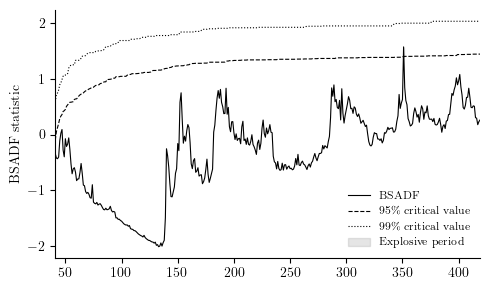

In [33]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_nobubble_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_nobubble_cv.csv")
t = P_nobubble.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_nobubble_bsadf.pdf", bbox_inches="tight")
plt.show()

### Random walk with with drift - 3 bubbles (simulating dot-com, corona, and AI)

If we define bubble periods as:

- dot-com bubble: january 1995 -> october 2002
- covid bubble: april 2020 -> july 2021
- ai bubble: january 2023 -> december 2025

And the sample length as januar 1990 -> december 2025, then there are with monthly data: $(2025 - 1990 + 1)\cdot 12 = 432$ observations. Using the periods as above we get:

- dot-com bubble: 61 -> 154
- covid bubble: 364 -> 382
- ai bubble: 397 -> 432

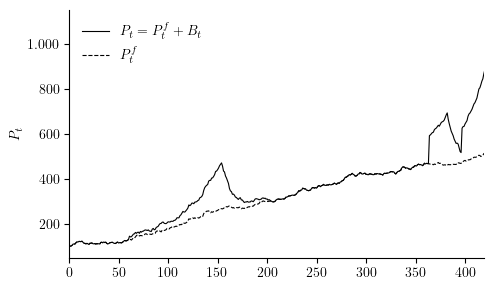

In [100]:
# simulate random walk with drift - 3 bubbles

Pf_3bubbles, B_3bubbles, P_3bubbles = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 432,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 1.0,
    sigma_f = 3.0,
    Pf0 = 100.0,

    # Bubble component
    include_bubble = True,
    R = 0.04,
    sigma_b = 4.0,
    omega = 0.9,
    B0 = 0.0,

    # a. First bubble interval (dot-com)
    tau_s1 = 61,
    tau_e1 = 154,
    B0_1 = 15.0,

    # b. Second bubble interval (COVID)
    tau_s2 = 364,
    tau_e2 = 382,
    B0_2 = 125.0,

    # c. Third bubble interval (AI)
    tau_s3 = 397,
    tau_e3 = 432,
    B0_3 = 150.0,

    # Random seed
    seed = 42,

)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_3bubbles.index, P_3bubbles.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.plot(Pf_3bubbles.index, Pf_3bubbles.values, color='black', linewidth=0.8, ls='--', label=r'$P_t^f$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P.index.min(), P.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_3bubbles.pdf')
P_3bubbles = P_3bubbles.rename('P_3bubbles')
P_3bubbles.to_csv('data/P_3bubbles.csv', index=False)
plt.show()

Next up, testing:

In [89]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/P_3bubbles.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$P_3bubbles)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/P_3bubbles_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/P_3bubbles_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  5.290168  6.366268  6.494763

  gsadf_panel
     6.494763


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



Now plotting BSADF

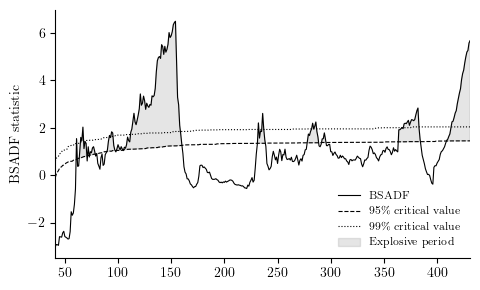

In [90]:
# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# data
bsadf_stat = pd.read_csv("results/P_3bubbles_bsadf.csv")
bsadf_cv   = pd.read_csv("results/P_3bubbles_cv.csv")
t = P_3bubbles.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))
plt.plot(t, bsadf_stat["bsadf"], color='black', linewidth=0.8, ls='-', label='BSADF')
plt.plot(t, bsadf_cv["95%"], color='black', linewidth=0.8, ls='--', label=r'95\% critical value')
plt.plot(t, bsadf_cv["99%"], color='black', linewidth=0.8, ls=':', label=r'99\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/P_3bubbles_bsadf.pdf", bbox_inches="tight")
plt.show()